# Bài 1 — Fine-tune CNN ResNet trên Spectrogram

Sử dụng bộ dữ liệu **ESC-50**. Chuyển tín hiệu âm thanh thành **Log-Mel Spectrogram** và sử dụng **ResNet18 pretrained trên ImageNet** để phân loại 50 lớp âm thanh.

## Yêu cầu

1. Điều chỉnh ResNet18 từ đầu vào ảnh RGB 3 kênh sang **Spectrogram 1 kênh**, tận dụng trọng số pretrained.
2. Thay lớp **Fully Connected** cuối để phù hợp với 50 lớp của ESC-50.
3. **Đóng băng phần lớn CNN**, chỉ fine-tune block CNN cuối cùng và lớp Fully Connected.
4. Huấn luyện, đánh giá mô hình trên tập test và nhận xét ngắn về ưu điểm/hạn chế của CNN khi xử lý Spectrogram.

> Được phép dùng ResNet18, Mel-Spectrogram, DataLoader, optimizer và các hàm huấn luyện có sẵn. Trọng tâm của bài là **điều chỉnh mô hình pretrained cho Spectrogram và selective fine-tuning**.

## 1. Setup

ESC-50 có 5 fold chính thức. Cả 3 bài dùng cùng quy ước:

- Train: fold 1, 2, 3
- Validation: fold 4
- Test: fold 5

Điều này giúp kết quả giữa ResNet, CRNN và DeiT có thể so sánh trực tiếp.

In [5]:
# Nếu chạy local và thiếu thư viện, cài trước:
# pip install torch torchvision torchaudio pandas matplotlib scikit-learn

from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
SAMPLE_RATE = 44_100
CLIP_SECONDS = 5
NUM_SAMPLES = SAMPLE_RATE * CLIP_SECONDS

N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 441          # xấp xỉ 100 frame/giây ở 44.1 kHz
NUM_CLASSES = 50

BATCH_SIZE = 32
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

Device: cuda


## 2. Dataset và đường dẫn

In [3]:
from pathlib import Path
import urllib.request
import zipfile

DATASET_URL = "https://github.com/karoldvl/ESC-50/archive/master.zip"
ZIP_PATH = Path("esc50_master.zip")
LOCAL_DATA_ROOT = Path("ESC-50-master")

# Chỉ tải nếu dataset chưa tồn tại
if (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists():
    print(f"Dataset đã tồn tại tại: {LOCAL_DATA_ROOT.resolve()}")
else:
    print("Đang tải ESC-50 (~600 MB)...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

    print("Đang giải nén...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")

    ZIP_PATH.unlink()  # Xóa file zip sau khi giải nén
    print(f"Hoàn tất. Dataset ở: {LOCAL_DATA_ROOT.resolve()}")

# Kiểm tra cấu trúc dữ liệu
assert (LOCAL_DATA_ROOT / "audio").exists()
assert (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists()

Đang tải ESC-50 (~600 MB)...
Đang giải nén...
Hoàn tất. Dataset ở: /content/ESC-50-master


In [7]:
from IPython.display import display
# =========================================================
# DATASET PATH — KAGGLE / MÁY CÁ NHÂN
# =========================================================
#
# Kaggle:
#   1) Add một dataset chứa ESC-50.
#   2) Notebook sẽ tự tìm file meta/esc50.csv trong /kaggle/input.
#
# Local:
#   Sửa LOCAL_DATA_ROOT thành thư mục ESC-50-master của bạn.
#   Cấu trúc mong đợi:
#       ESC-50-master/
#       ├── audio/
#       └── meta/esc50.csv
# =========================================================

LOCAL_DATA_ROOT = Path(r"./ESC-50-master")  # <-- Chỉ cần sửa dòng này khi chạy local.

def resolve_esc50_root():
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        matches = list(kaggle_input.glob("**/meta/esc50.csv"))
        if matches:
            root = matches[0].parent.parent
            print("Tìm thấy ESC-50 trên Kaggle:", root)
            return root

    if (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists():
        print("Dùng ESC-50 local:", LOCAL_DATA_ROOT)
        return LOCAL_DATA_ROOT

    raise FileNotFoundError(
        "Không tìm thấy ESC-50. Hãy Add Dataset trên Kaggle hoặc sửa LOCAL_DATA_ROOT."
    )

DATA_ROOT = resolve_esc50_root()
META_CSV = DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = DATA_ROOT / "audio"

metadata = pd.read_csv(META_CSV)
print("Số mẫu:", len(metadata))
display(metadata.head())

Dùng ESC-50 local: ESC-50-master
Số mẫu: 2000


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## 3. Tiền xử lý Log-Mel Spectrogram

In [8]:
# =========================================================
# PREPROCESSING: waveform -> Log-Mel Spectrogram
# =========================================================

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=0.0,
    f_max=SAMPLE_RATE / 2,
    power=2.0,
)

db_transform = torchaudio.transforms.AmplitudeToDB(stype="power")

class ESC50Dataset(Dataset):
    def __init__(self, dataframe, audio_dir, resize_to=None):
        self.df = dataframe.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.resize_to = resize_to

    def __len__(self):
        return len(self.df)

    @staticmethod
    def _fix_length(waveform):
        if waveform.shape[-1] < NUM_SAMPLES:
            waveform = F.pad(waveform, (0, NUM_SAMPLES - waveform.shape[-1]))
        else:
            waveform = waveform[..., :NUM_SAMPLES]
        return waveform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav_path = self.audio_dir / row["filename"]

        waveform, sr = torchaudio.load(wav_path)

        # ESC-50 là mono, nhưng vẫn xử lý an toàn nếu file có nhiều kênh.
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

        waveform = self._fix_length(waveform)

        spec = mel_transform(waveform)
        spec = db_transform(spec)

        # Chuẩn hóa riêng từng spectrogram để ổn định fine-tuning.
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)

        if self.resize_to is not None:
            spec = F.interpolate(
                spec.unsqueeze(0),
                size=self.resize_to,
                mode="bilinear",
                align_corners=False,
            ).squeeze(0)

        label = int(row["target"])
        return spec.float(), label

# Dùng fold chính thức của ESC-50 để ba notebook so sánh công bằng:
# Train: fold 1,2,3 | Validation: fold 4 | Test: fold 5
train_df = metadata[metadata["fold"].isin([1, 2, 3])].copy()
val_df   = metadata[metadata["fold"] == 4].copy()
test_df  = metadata[metadata["fold"] == 5].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 1200 | Val: 400 | Test: 400


/usr/local/lib/python3.13/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Spectrogram shape: (1, 128, 501)
Label: 0 - dog


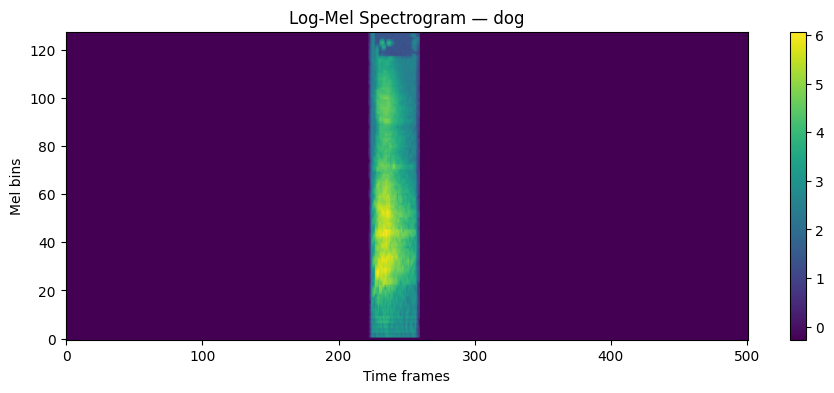

In [9]:
# =========================================================
# VISUALIZE MỘT MẪU — phần minh họa, KHÔNG phải TODO
# =========================================================

preview_ds = ESC50Dataset(train_df, AUDIO_DIR)
spec, label = preview_ds[0]

label_name = train_df.iloc[0]["category"]
print("Spectrogram shape:", tuple(spec.shape))
print("Label:", label, "-", label_name)

plt.figure(figsize=(11, 4))
plt.imshow(spec.squeeze(0).numpy(), origin="lower", aspect="auto")
plt.title(f"Log-Mel Spectrogram — {label_name}")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

In [10]:
train_ds = ESC50Dataset(train_df, AUDIO_DIR)
val_ds   = ESC50Dataset(val_df, AUDIO_DIR)
test_ds  = ESC50Dataset(test_df, AUDIO_DIR)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

x, y = next(iter(train_loader))
print("Batch spectrogram:", tuple(x.shape))
print("Batch labels:", tuple(y.shape))

Batch spectrogram: (32, 1, 128, 501)
Batch labels: (32,)


## 4. ResNet18 pretrained

ResNet18 pretrained trên ImageNet nhận ảnh RGB 3 kênh, trong khi Log-Mel Spectrogram trong bài là 1 kênh.

Ta giữ lại tri thức pretrained bằng cách thay `conv1` bằng convolution 1 kênh và khởi tạo trọng số mới từ **trung bình ba kênh RGB**.

In [11]:
from torchvision.models import resnet18, ResNet18_Weights

def build_resnet18_for_spectrogram(num_classes=NUM_CLASSES):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    # =========================================================
    # TODO 1: ĐIỂU CHỈNH INPUT 3 KÊNH -> 1 KÊNH
    # - Tạo conv1 mới nhận 1 input channel.
    # - Giữ nguyên kernel_size, stride, padding, bias của conv1 cũ.
    # - Khởi tạo weight mới bằng trung bình weight pretrained theo chiều RGB.
    # =========================================================
    old_conv = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None,
    )

    # Trung bình trọng số pretrained của 3 kênh RGB
    with torch.no_grad():
        model.conv1.weight.copy_(
            old_conv.weight.mean(dim=1, keepdim=True)
        )

    # =========================================================
    # TODO 2: THAY CLASSIFICATION HEAD
    # - Thay model.fc để output đúng NUM_CLASSES lớp.
    # =========================================================
    model.fc = nn.Linear(model.fc.in_features, num_classes)


    return model

### Selective fine-tuning

Ở bài này ta chỉ fine-tune `layer4` và `fc`. Các phần trước đóng vai trò feature extractor đã học từ ImageNet.

In [12]:
def configure_resnet_finetuning(model):
    # =========================================================
    # TODO 3: FREEZE / UNFREEZE
    # - Freeze toàn bộ tham số trước.
    # - Chỉ mở layer4 và fc để train.
    # =========================================================
    for param in model.parameters():
        param.requires_grad = False

    # Chỉ fine-tune block ResNet cuối
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Và lớp phân loại cuối
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

set_seed()
model = build_resnet18_for_spectrogram()
model = configure_resnet_finetuning(model).to(DEVICE)

total_params, trainable_params = count_parameters(model) if "count_parameters" in globals() else (
    sum(p.numel() for p in model.parameters()),
    sum(p.numel() for p in model.parameters() if p.requires_grad),
)

print(model)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s] 


ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 5. Quick shape test

In [13]:
x, _ = next(iter(train_loader))
with torch.no_grad():
    logits = model(x[:2].to(DEVICE))

print("Input :", tuple(x[:2].shape))
print("Output:", tuple(logits.shape))
assert logits.shape == (2, NUM_CLASSES)

Input : (2, 1, 128, 501)
Output: (2, 50)


## 6. Huấn luyện và đánh giá

In [14]:
# =========================================================
# TRAIN / EVALUATE HELPERS
# =========================================================

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_targets = []
    all_preds = []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)

        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

        all_targets.extend(y.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "targets": all_targets,
        "preds": all_preds,
    }

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_samples += x.size(0)

        train_loss = running_loss / running_samples
        train_acc = running_correct / running_samples

        val_result = evaluate(model, val_loader, criterion)
        val_loss = val_result["loss"]
        val_acc = val_result["accuracy"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss={train_loss:.4f}, acc={train_acc:.4f} | "
            f"val loss={val_loss:.4f}, acc={val_acc:.4f}"
        )

    training_seconds = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc, training_seconds

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.show()

Epoch 01/10 | train loss=3.2282, acc=0.2367 | val loss=2.8868, acc=0.2850
Epoch 02/10 | train loss=1.6663, acc=0.7358 | val loss=1.8056, acc=0.5650
Epoch 03/10 | train loss=1.0034, acc=0.8733 | val loss=1.3728, acc=0.6825
Epoch 04/10 | train loss=0.6290, acc=0.9350 | val loss=1.1977, acc=0.7400
Epoch 05/10 | train loss=0.4093, acc=0.9700 | val loss=1.1394, acc=0.7225
Epoch 06/10 | train loss=0.2602, acc=0.9900 | val loss=1.0516, acc=0.7350
Epoch 07/10 | train loss=0.1658, acc=0.9958 | val loss=1.0323, acc=0.7300
Epoch 08/10 | train loss=0.1123, acc=0.9992 | val loss=0.9687, acc=0.7625
Epoch 09/10 | train loss=0.0777, acc=1.0000 | val loss=0.9388, acc=0.7475
Epoch 10/10 | train loss=0.0577, acc=1.0000 | val loss=0.9315, acc=0.7575


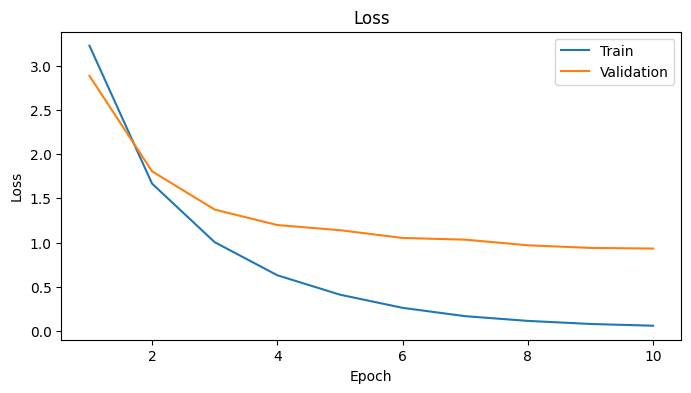

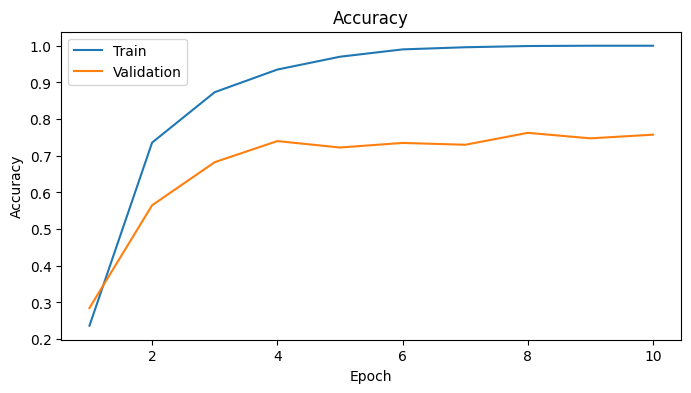

Best validation accuracy: 0.7625
Test accuracy: 0.7225
Training time (s): 251.33


In [ ]:
EPOCHS = 10
LEARNING_RATE = 1e-4

set_seed()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

history, best_val_acc, training_seconds = train_model(
    model, train_loader, val_loader, optimizer, criterion, EPOCHS
)

torch.save(model.state_dict(), "resnet18_esc50_best.pt")

test_result = evaluate(model, test_loader, criterion)
plot_history(history)

print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Test accuracy: {test_result['accuracy']:.4f}")
print(f"Training time (s): {training_seconds:.2f}")

## 7. Kết quả và nhận xét

Ghi lại:

- Best validation accuracy:
- Test accuracy:
- Trainable parameters:
- Training time:

**Câu hỏi:** CNN có ưu điểm gì khi học các mẫu cục bộ trên Spectrogram? Vì sao tính bất biến tịnh tiến theo **trục tần số** có thể không hoàn toàn phù hợp với âm thanh?

- Best validation accuracy: **76.25%**
- Test accuracy: **72.25%**
- Trainable parameters: **8,419,378**
- Training time: **251.33 giây** (khoảng 4.2 phút, chạy GPU)

**Nhận xét:**

Mô hình đạt validation accuracy cao nhất là 76.25% ở epoch 8 và test accuracy là 72.25%. Kết quả cho thấy ResNet18 pretrained có thể học khá tốt đặc trưng từ Log-Mel Spectrogram, dù mô hình ban đầu được huấn luyện trên ảnh tự nhiên. Việc chỉ fine-tune `layer4` và `fc` giúp tận dụng các trọng số pretrained, đồng thời giảm chi phí huấn luyện so với train toàn bộ mạng.

Tuy nhiên, mô hình có dấu hiệu overfitting: train accuracy tăng đến 100% từ epoch 9, trong khi validation accuracy chỉ dao động khoảng 72–76%. Nguyên nhân có thể là số mẫu train của ESC-50 tương đối nhỏ (1,200 mẫu) nhưng số tham số được train vẫn lớn, khoảng 8.4 triệu. Có thể cải thiện bằng data augmentation cho audio, dropout, weight decay mạnh hơn, hoặc early stopping tại epoch có validation accuracy tốt nhất.

CNN có ưu điểm là học tốt các mẫu cục bộ trên spectrogram, ví dụ các dải năng lượng, harmonic, tiếng gõ ngắn, hoặc cấu trúc thay đổi theo thời gian. Các kernel convolution dùng chung trọng số cũng giúp giảm số tham số và phát hiện cùng một mẫu ở các vị trí thời gian khác nhau.

Tuy nhiên, tính bất biến tịnh tiến theo trục tần số không hoàn toàn phù hợp với âm thanh. Dịch một đặc trưng lên hoặc xuống theo tần số có thể thay đổi ý nghĩa âm thanh, chẳng hạn cao độ của nốt nhạc, formant của giọng nói, hoặc đặc tính harmonic. Vì vậy, hai trục thời gian và tần số của spectrogram không có tính tương đương hoàn toàn như hai chiều không gian trong ảnh.